In [6]:
### Configuration of Chipwhispere to run ascon implementation
import chipwhisperer as cw
import time

fw_path = "./simpleserial-ascon-CWHUSKY.hex"

scope = cw.scope()
target = cw.target(scope)

print("Found ChipWhisperer!")
scope.default_setup()
    
if hasattr(scope.io, 'target_pwr'):
    scope.io.target_pwr = 'high'
    
print(f"Programming: {fw_path}")
cw.program_target(scope, cw.programmers.SAM4SProgrammer, fw_path)

print("Resetting target...")
scope.io.nrst = 'low'
time.sleep(0.05)
scope.io.nrst = 'high'
time.sleep(0.3)
    
target.flush()


Found ChipWhisperer!
scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 131124                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7363636.363636363        
scope.clock.adc_freq                     changed from 0                         to 29454545.454545453       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2                            changed from serial_rx                 to serial_tx                
scope.io.hs2                             changed from None                      to clkgen                   
scope.glitch.phase_shift_steps           changed from 0                         to 4592                    

In [7]:
def calculate_r8(IV, N_128, K_128):
    # --- Constants ---
    MASK_64 = 0xFFFFFFFFFFFFFFFF
    MASK_32 = 0xFFFFFFFF

    # --- 1. Split 128-bit inputs into 64-bit words (Little-Endian) ---
    # N0/K0 are the first 8 bytes (Lower 64 bits)
    # N1/K1 are the second 8 bytes (Upper 64 bits)
    
    N0 = N_128 & MASK_64          # Lower 64 bits
    N1 = (N_128 >> 64) & MASK_64  # Upper 64 bits
    
    K0 = K_128 & MASK_64          # Lower 64 bits
    K1 = (K_128 >> 64) & MASK_64  # Upper 64 bits

    # --- 2. Extract Low 32-bit words for the specific instruction ---
    # The instruction uses:
    #   r2 (derived from IV and N1)
    #   sl (derived from K0)
    
    iv_low = IV & MASK_32
    n1_low = N1 & MASK_32  # r5 in assembly
    k0_low = K0 & MASK_32  # sl in assembly

    # --- 3. Simulate Assembly Logic ---
    
    # Instruction 400410: eors r2, r5
    # Logic: r2 = IV_low ^ N1_low
    r2_val = iv_low ^ n1_low

    # Instruction 40044c: bic.w r8, sl, r2
    # Logic: r8 = K0_low & ~(r2)
    # Note: We apply MASK_32 after NOT (~) to handle Python's infinite integers
    r8_val = k0_low & (~r2_val & MASK_32)

    return hamming_weight(r8_val)

def hamming_weight(n):
    return bin(n).count('1')

In [27]:
import random
from tqdm.notebook import trange
import numpy as np
import time
import secrets

# Fix 1: Create separate bytearrays
pt = bytearray([0] * 16)
ad = bytearray([0] * 16)

ktp = cw.ktp.Basic()
key, text = ktp.next()
trace_array = []
nonce_array = []
keys_array = []
hamming_weights = []
ASCON_128A_IV = 0x1000808c0001
N = 1000

for i in trange(N, desc='Capturing traces'):
    nonce = secrets.token_bytes(16)
    nonce_int = int.from_bytes(nonce, byteorder="little")
    key_int   = int.from_bytes(key,   byteorder="little")
    # Send key
    target.simpleserial_write('k', key)
    time.sleep(0.01)
    
    # Send nonce
    target.simpleserial_write('n', nonce)
    time.sleep(0.01)
    
    # Send length configuration
    len_config = bytearray([len(ad), len(pt)]) + bytearray([0] * 14)
    target.simpleserial_write('l', len_config)
    time.sleep(0.01)
    
    # Send associated data
    target.simpleserial_write('a', ad)
    time.sleep(0.01)  # Add delay before arming
    
    # Arm scope and send plaintext
    scope.arm()
    time.sleep(0.001) 
    target.simpleserial_write('p', pt)
    
    # Capture trace
    ret = scope.capture()
    if ret:
        print(f"Target timed out on iteration {i}!")
        continue
    
    # Read response (ciphertext + 16-byte tag)
    expected_response_len = len(pt) + 16
    try:
        response = target.simpleserial_read('r', expected_response_len, timeout=1000)
        
        if response is None:
            print(f"No response received on iteration {i}!")
            continue
    except Exception as e:
        print(f"Error reading response on iteration {i}: {e}")
        continue
    
    # Store trace
    trace = scope.get_last_trace()
    if trace is not None:
        nonce_array.append(nonce)
        keys_array.append(key)
        hamming_weights.append(calculate_r8(ASCON_128A_IV, nonce_int, key_int))
        trace_array.append(trace)

print(f"\nCaptured {len(trace_array)} traces successfully.")

Capturing traces:   0%|          | 0/1000 [00:00<?, ?it/s]


Captured 1000 traces successfully.


In [28]:
with open("ascon_cpa_dataset.txt", "w") as f:
    for i in range(len(trace_array)):
        key_int   = int.from_bytes(keys_array[i], byteorder="little")
        nonce_int = int.from_bytes(nonce_array[i], byteorder="little")
        
        row = [
            hamming_weights[i],
            key_int,
            nonce_int,
            *trace_array[i]
        ]
        f.write(" ".join(map(str, row)) + "\n")

In [29]:
import numpy as np

# Load entire file
data = np.loadtxt("ascon_cpa_dataset.txt")

# Split columns
hw     = data[:, 0]        # shape (N,)
keys   = data[:, 1]        # shape (N,)
nonces = data[:, 2]        # shape (N,)
traces = data[:, 3:]       # shape (N, T)

print("Traces shape:", traces.shape)
print("HW shape:", hw.shape)

Traces shape: (1000, 5000)
HW shape: (1000,)


In [30]:
print("traces shape:", traces.shape)  # (N, T)
print("HW shape:", hw.shape)          # (N,)
print("nonces shape:", nonces.shape)  # (N,)
print("keys shape:", keys.shape)      # (N,)

traces shape: (1000, 5000)
HW shape: (1000,)
nonces shape: (1000,)
keys shape: (1000,)


In [31]:
assert all(len(trace) == len(traces[0]) for trace in traces)

In [32]:
# Center traces and HW
traces_centered = traces - traces.mean(axis=0)  # center each time sample
hw_centered     = hw - hw.mean()                # center labels

# Numerator: covariance
numerator = np.dot(hw_centered, traces_centered)

# Denominator: product of standard deviations
denominator = np.sqrt(np.sum(hw_centered ** 2) * np.sum(traces_centered ** 2, axis=0))

# Pearson correlation coefficient per time sample
correlation = numerator / denominator

print("Correlation array shape:", correlation.shape)  # (T,)


Correlation array shape: (5000,)


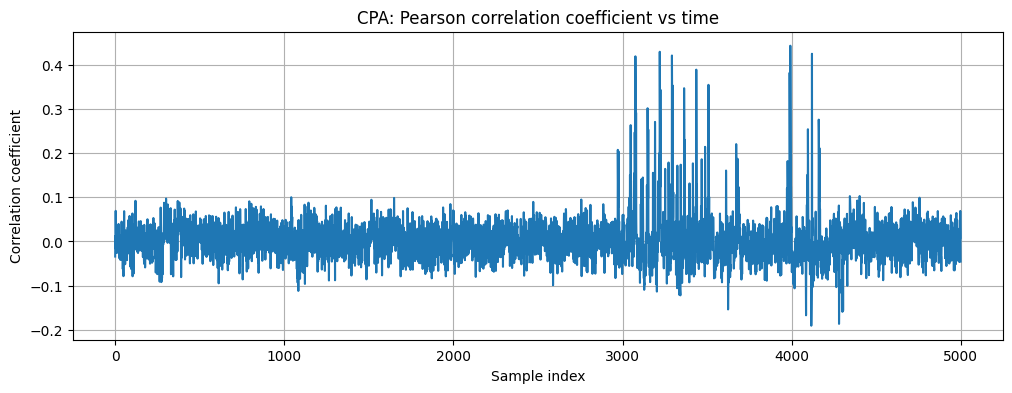

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(correlation)
plt.title("CPA: Pearson correlation coefficient vs time")
plt.xlabel("Sample index")
plt.ylabel("Correlation coefficient")
plt.grid(True)
plt.show()
